# Q1. Supervised Learning

Build and evaluate classification models to predict whether a patient has heart disease.

## 1. Data Loading and Inspection

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv("../data/q1_heart_disease.csv")
print("Shape of the dataset:", data.shape)
print("")
print("Data Types:")
data.dtypes

Shape of the dataset: (800, 12)

Data Types:


age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

In [24]:
print("Missing Values:")
data.isnull().sum()

Missing Values:


age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

In [25]:
print("First 5 rows of the dataset:")
data.head()

First 5 rows of the dataset:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## 2. Exploratory Data Analysis

### 2.1 Target class distribution Plot

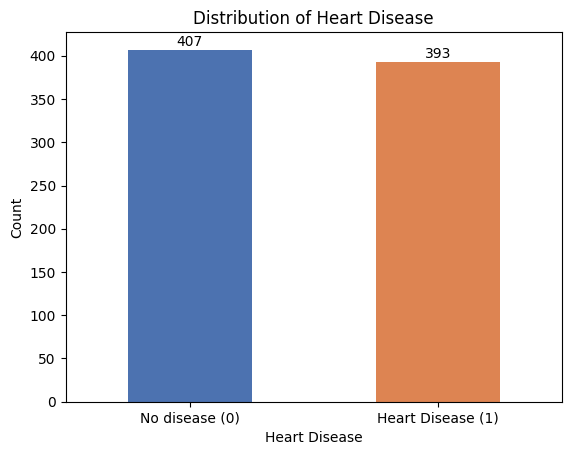

In [26]:
target_counts = data["heart_disease"].value_counts()
ax = target_counts.plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_xlabel("Heart Disease")
ax.set_ylabel("Count")
ax.set_xticklabels(["No disease (0)", "Heart Disease (1)"], rotation=0)
ax.set_title("Distribution of Heart Disease")
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 5, str(v), ha="center")
plt.show()

**Plot Interpretation:** Both categorizations - "Heart Disease" and "No Disease" both are almost evenly represented in the data set - close to a 50-50 split. While plain accuracy may not be misleading in this case, the risk of a false negative - misdiagnosis of a disease case as healthy may present a significant cost. Hence, we should also report precision and recall.

### 2.2 Correlation Heatmap Plot

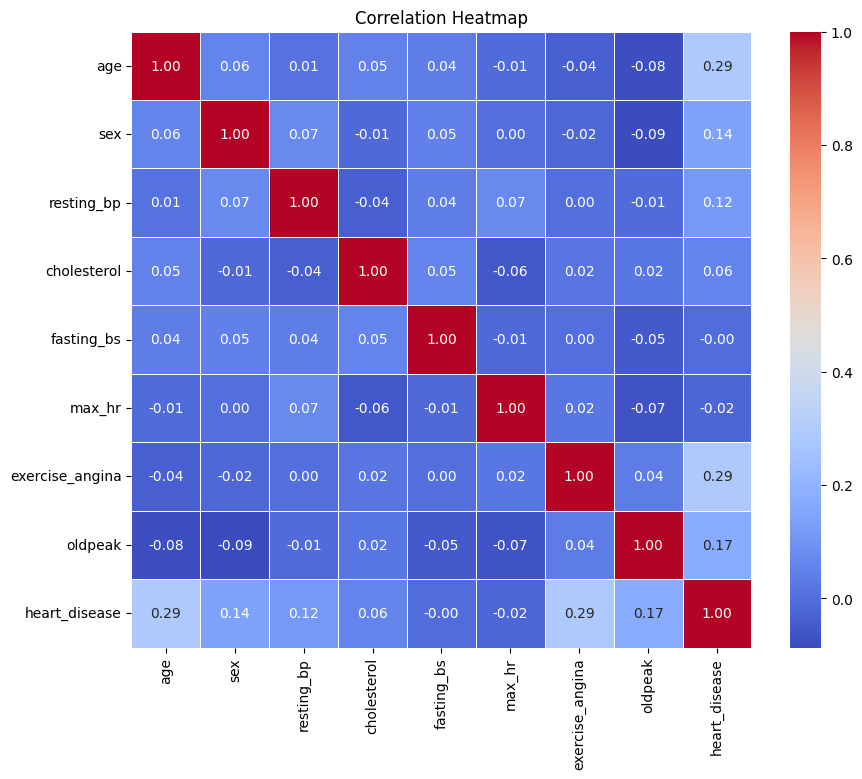

In [36]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
corr = data[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
ax.set_title("Correlation Heatmap")
plt.show()

**Plot Inferences:** "age" (0.29), "exercise_angina" (0.29) and "oldpeak" (0.17) show strong positive correlation with Heart Disease, whereas "fasting_bs" and "max_hr" show no to very little correlation with Heart disease. This is in line with typical expectations. Also, we can also note that none of the predictors are strongly correlated to each other, which reduces the potential for multi-collinearity being an immediate concern in the analysis.

### 2.3 Stacked Bar Plot (Chest pain type vs Heart Disease)

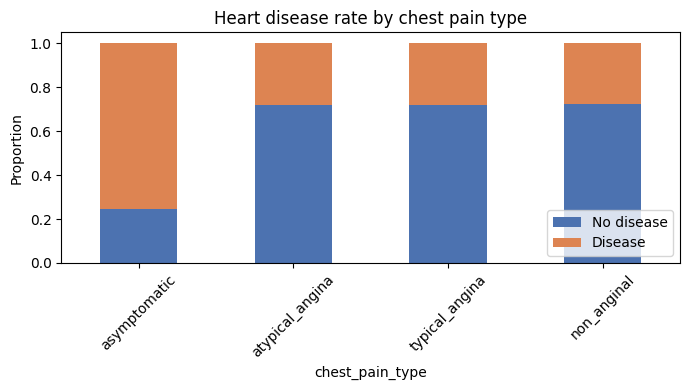

In [28]:
cp = pd.crosstab(data["chest_pain_type"], data["heart_disease"], normalize="index")
cp = cp.sort_values(1, ascending=False)
ax = cp.plot(kind="bar", stacked=True, color=["#4C72B0", "#DD8452"], figsize=(7, 4))
ax.set_ylabel("Proportion")
ax.set_title("Heart disease rate by chest pain type")
ax.legend(["No disease", "Disease"], loc="lower right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Plot Inference:** 'asymptomatic' pain type shows up as the most predictive indicator of heart disease, as compared to the other types of pain. 

## 3. Data Preprocessing

**Median imputation approach.** Only 'resting_bp' (3 % missing) and 'cholesterol' (4 % missing) have gaps, and both are continuous clinical measurements whose distributions are roughly symmetric but they also contain outliers. Dropping 56 patients would throw away ~7 % of a relatively small dataset, hence we impute with the **median** of the training set — robust to outliers and preserves sample size. We fit the imputer on the training set only to avoid leakage.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

target = "heart_disease"
categorical = ["chest_pain_type", "resting_ecg", "st_slope"]
numerical = [c for c in data.columns if c not in categorical + [target]]

X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape, "Testing set shape:", X_test.shape)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical),
    ("cat", categorical_transformer, categorical)
])

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)
print("Transformed training set shape:", X_train_t.shape, "Transformed testing set shape:", X_test_t.shape)

Training set shape: (640, 11) Testing set shape: (160, 11)
Transformed training set shape: (640, 18) Transformed testing set shape: (160, 18)


## 4. Model Training

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_t, y_train)
    print(f"{name} trained.")

Decision Tree trained.
Random Forest trained.
Gradient Boosting trained.


## 5. Model Evaluation

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score

rows = []
for name, model in models.items():
    y_pred = model.predict(X_test_t)
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"Precision: {precision_score(y_test, y_pred):.2f}")
    print(f"Recall: {recall_score(y_test, y_pred):.2f}")
    print("")
    rows.append({
        "model": name,
        "precision": precision_score(y_test, y_pred),
        "recall":    recall_score(y_test, y_pred),
    })

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.71      0.77      0.74        75
           1       0.78      0.72      0.75        85

    accuracy                           0.74       160
   macro avg       0.74      0.75      0.74       160
weighted avg       0.75      0.74      0.74       160

Confusion Matrix:
[[58 17]
 [24 61]]
Precision: 0.78
Recall: 0.72

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.79      0.80      0.79        75
           1       0.82      0.81      0.82        85

    accuracy                           0.81       160
   macro avg       0.81      0.81      0.81       160
weighted avg       0.81      0.81      0.81       160

Confusion Matrix:
[[60 15]
 [16 69]]
Precision: 0.82
Recall: 0.81

--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        75
           1       0.82      0.82

In [32]:
summary = pd.DataFrame(rows).set_index("model").round(3)
summary["precision", "recall"] = summary[["precision", "recall"]].mean(axis=1)
best_model_name = summary["precision", "recall"].idxmax()
print(f"Best model by precision and recall: {best_model_name}")
print(summary.loc[[best_model_name]])

Best model by precision and recall: Gradient Boosting
                   precision  recall  (precision, recall)
model                                                    
Gradient Boosting      0.824   0.824                0.824


**Model Evaluation Inferences:**
**1. ** Both the 'Random Forest' and 'Gradient Boosting' models are very close in performance and superior to 'Decision Tree' model.
**2. ** Looking at the confusion matrix, the 'Gradient Boosting' model has a slight edge over the 'Random Forest' model in terms of overall accuracy and recall while identifying cases with heart disease
**3. ** Looking at the raw counts in the confusion matrix, 'Gradient Boosting' predicted 130 instances correctly over the 129 predicted by the 'Random Forest' model
**4. ** Also, 'Gradient Boosting' has one less False-Negative as compared to the 'Random Forest' model.

**Conclusion:**
The 'Decision Tree' model is obviously the weakest model here. This maybe due to the inherent complexity in the dataset. While both the 'Random Forest' and 'Gradient Boosting' models are almost equally good, I think the 'Gradient Boosting' model is slightly better since it shows better performance in both accuracy and recall. Moreover, it has a lesser incidence of False-Negatives. In real-world scenarios, False-Negatives can prove very expensive, especially in medical diagnosis, since missing a positive case can be quite fatal.

## 6. Hyperparameter Tuning

In [33]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    "Gradient Boosting": {
        "n_estimators":  [100, 200, 300],
        "learning_rate": [0.05, 0.1, 0.2],
        "max_depth":     [2, 3, 4],
    },
    "Random Forest": {
        "n_estimators":      [100, 200, 400],
        "max_depth":         [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10],
    },
    "Decision Tree": {
        "max_depth":         [None, 3, 5, 8, 12],
        "min_samples_split": [2, 5, 10],
    },
}

baseline = models[best_model_name]
gs = GridSearchCV(
    baseline.__class__(random_state=42),
    param_grid=param_grids[best_model_name],
    scoring="f1",
    cv=5,
    n_jobs=-1,
)
gs.fit(X_train_t, y_train)
print(f"Tuned model: {best_model_name}")
print("Best params:", gs.best_params_)
print(f"Best CV F1:  {gs.best_score_:.3f}")


Tuned model: Gradient Boosting
Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Best CV F1:  0.816


In [34]:
tuned = gs.best_estimator_

def score(model, name):
    p = model.predict(X_test_t)
    return {
        "model":     name,
        "precision": precision_score(y_test, p),
        "recall":    recall_score(y_test, p),
    }

comparison = pd.DataFrame([
    score(baseline, f"{best_model_name} (baseline)"),
    score(tuned,    f"{best_model_name} (tuned)"),
]).set_index("model").round(3)
comparison

,precision,recall
model,,
Gradient Boosting (baseline),0.824,0.824
Gradient Boosting (tuned),0.812,0.812


**Inference from Hypertuning Results:**
The tuned 'Gradient Boosting' model actually performs marginally lower than the default model used, on both precision and recall. This indicates that the default model is more effective on the specific dataset provided and tuning was not needed.